# Efficient Calibration of the Heston Stochastic Volatility Model using Numerical Optimization

## 1. Introduction

The dynamics of the Heston model are defined by the system:

$$
dS_t = \mu S_t \, dt + \sqrt{v_t} S_t \, dW_t^S
$$

$$
dv_t = \kappa(\theta - v_t)\, dt + \sigma \sqrt{v_t} \, dW_t^v
$$

$$
dW_t^S \, dW_t^v = \rho \, dt
$$

where $S_t$ denotes the asset price, $v_t$ the instantaneous variance, $\kappa$ the rate of mean reversion, $\theta$ the long-term variance, $\sigma$ the volatility of volatility, and $\rho$ the correlation between the asset price and variance processes.

In practical applications, the model parameters are not directly observable and must be determined through calibration. This is achieved by solving the following optimization problem:

$$
\min_{\kappa,\theta,\sigma,\rho,v_0} \sum_{i=1}^{N} \left( C_{\text{model}}(K_i,T_i) - C_{\text{market}}(K_i,T_i) \right)^2
$$

where $C_{\text{model}}$ represents the model-generated option price and $C_{\text{market}}$ denotes the observed market price for strike $K_i$ and maturity $T_i$.

A key challenge in this calibration process is the high computational cost and numerical instability. The optimization problem is non-linear, often exhibits multiple local minima, and is sensitive to initial parameter values. Additionally, repeated evaluation of option prices under the Heston model can be computationally expensive, making the calibration process slow and inefficient.

This motivates the need for efficient numerical methods that enhance both efficiency and stability. Recent research such as *On Multilevel and Control Variate Monte Carlo Methods for Option Pricing under the Rough Heston Model* highlights the importance of reducing computational cost and improving performance in stochastic volatility models. Inspired by these ideas, this project focuses on developing a more efficient and robust calibration framework for the Heston model.

## 3. Calibration Problem Formulation

Calibrating the Heston model means choosing the five model parameters that make the theoretical option surface look as much like the observed market surface as possible. 
Because Heston has no closed-form inverse (unlike Black–Scholes, where each option uniquely implies one volatility), this recovery step has to be posed as a numerical optimization.

### 3.1 Optimization statement

Let the Heston parameter vector be

$$\theta = (v_0,\ \kappa,\ \theta_{\infty},\ \eta,\ \rho),$$

where $v_0$ is the initial variance, $\kappa$ the mean-reversion speed, $\theta_\infty$ the long-run variance, $\eta$ the vol-of-vol, and $\rho$ the spot–variance correlation. 
For a fixed valuation date, the grid of quoted tenors and strikes defines a surface of market prices $\{C^{\text{mkt}}_{i,j},\ P^{\text{mkt}}_{i,j}\}$ for $i \in \text{tenors}$, $j \in \text{strikes}$. 
The calibration problem is

$$\hat{\theta} \;=\; \arg\min_{\theta \,\in\, \Theta} \; \mathcal{L}(\theta),$$

subject to the parameter box $\Theta$ that enforces economic validity ($v_0, \theta_\infty > 0$, $\kappa, \eta > 0$, $\rho \in (-1, 1)$).

### 3.2 Objective function

The implementation uses mean squared error across the full surface, counting calls and puts as separate observations:

$$\mathcal{L}(\theta) \;=\; \frac{1}{2\,N_T N_K} \sum_{i=1}^{N_T} \sum_{j=1}^{N_K} \Big[\big(C^{\text{mkt}}_{i,j} - C^{\text{Heston}}_{i,j}(\theta)\big)^2 + \big(P^{\text{mkt}}_{i,j} - P^{\text{Heston}}_{i,j}(\theta)\big)^2\Big].$$

In code (`calculate_mse_entire`), this is the sum of squared call and put errors divided by the total point count (`count += 2` per strike × tenor cell). 
Squared error is chosen because it is smooth and differentiable — both needed by L-BFGS-B — and because it penalises large mispricings disproportionately, which matters more for hedging risk than uniform small errors.

Alternative objective functions worth noting:
- **Weighted MSE** using bid–ask spread as the per-point weight, to downweight illiquid deep wings.
- **Relative error** ($|C^{\text{mkt}} - C^{\text{Heston}}| / C^{\text{mkt}}$), which prevents expensive ATM options from dominating.
- **Implied-vol MSE**, which matches the surface in vol space rather than price space. More common in practice but adds a root-finding step per evaluation.

### 3.3 Inputs

Firstly, we obtained daily implied volatility surfaces data on SPX option from January 2012 to 2025 October from Bloomberg Terminal. These implied volatilities are computed such that the BSM option price matches with the historical option market price. Strikes are quoted as a percentage of spot.



| Input | Source | 
|---|---|
| Spot $S_0$ | `Underlying` sheet, `Mid` column |
| Risk-free rate $r$ | `Other` sheet, `Interest` column | 
| Dividend yield $q$ | `Other` sheet, `Dividend` column | 
| Strikes | `VALID_STRIKE` = `[30, 40, 60, 80, 90, 95, 97.5, 100, 105, 110, 120, 130, 150, 300]` (% of spot) | 
| Tenors | `VALID_TENOR` = `1W`–`2Y`, 11 expiries | 
| Market prices | `blackScholes(...)` applied to quoted implied vols | 




### 3.4 Parameter space and initial guess

We selected the 1M ATM Volatility to be initial guess for inital variance in the Heston Model. We initialized vov as 0.5 and spot/vol correlation as -0.5

In [ ]:
initial_guess = [atm_vol**2,  2.0,  atm_vol**2,  0.5,  -0.5]

bounds = [
    (1e-6, 2.0),     # v0
    (1e-4, 20.0),    # kappa
    (1e-6, 2.0),     # theta
    (1e-4, 5.0),     # eta
    (-0.999, 0.999), # rho
]

### 3.5 Optimization

The code uses `scipy.optimize.minimize` with **L-BFGS-B**, a quasi-Newton gradient method with box constraints. 
The choice trades global coverage for speed — L-BFGS-B is fast but local. 
Robustness is handled through the initial guess (seeded from market ATM vol so it starts inside the right basin) and through guarded return values inside `objective(x)`:

In [ ]:
if not np.isfinite(heston_call) or not np.isfinite(heston_put):
    return 1e12

so that numerically unstable parameter combinations don't crash the optimizer but look unattractive to it instead.

### 3.6 Challenges

#### Non-linearity

$C^{\text{Heston}}(\theta)$ depends on $\theta$ through a characteristic function and an inverse Fourier transform (`pf.HestonFft`). 
This is smooth but highly non-linear: $\kappa$ and $\theta_\infty$ enter exponentially through the CIR variance mean, $\rho$ enters as a cross-term in the drift of the log-price, and $\eta$ multiplies a Brownian increment inside the variance SDE. 
The loss surface $\mathcal{L}(\theta)$ inherits all of this — no convexity guarantees.

#### Multiple local minima

The Heston calibration problem is *well-documented* to be non-convex. 
The classic symptom is the $\kappa$–$\theta_\infty$–$\eta$ trade-off: several combinations produce nearly identical long-dated smiles, differing only in how they extrapolate to tenors outside the calibration grid. 
The Feller condition $2\kappa\theta_\infty \ge \eta^2$ carves the parameter space further, and near-equivalent minima can straddle it.

Practical mitigations (not all implemented here):
- **Multi-start** — run L-BFGS-B from several initial points and keep the best minimum.
- **Global-then-local** — differential evolution or CMA-ES first to get into a good basin, L-BFGS-B to polish.
- **Regularization** — add a small penalty toward economically reasonable parameters to break near-flat directions in the loss.

#### Sensitivity to initial guesses

Because the solver is local, the answer depends on `initial_guess`. 
The current seeding ($v_0 = \theta_\infty = \sigma_{\text{ATM,1M}}^2$, $\kappa=2$, $\eta=0.5$, $\rho=-0.5$) is a reasonable equity default, but there is no guarantee this is the basin of the global optimum on a given date. 
A sensitivity check worth running: perturb the initial guess by ±30% on each component, re-calibrate, and record the spread in final parameters. 
Small final-parameter dispersion ⇒ well-identified calibration; large dispersion ⇒ surface doesn't pin down all five parameters on this date and regularization is needed.

## 4. Baseline Method (Naive Approach)

As a benchmark, the baseline method uses a standard local optimization approach to calibrate the Heston model parameters. The market targets are constructed from the SPY implied volatility surface by converting mid implied volatilities into call and put option prices using the Black–Scholes formula.

The baseline calibration problem is formulated as

$$
\min_{\theta \in \Theta} \mathcal{L}(\theta)
$$

where the Heston parameter vector is

$$
\theta = (v_0, \kappa, \theta_{\infty}, \eta, \rho)
$$

and the mean squared pricing error is

$$
\mathcal{L}(\theta)
=
\frac{1}{2N_TN_K}
\sum_{i=1}^{N_T}
\sum_{j=1}^{N_K}
\left[
\left(C^{mkt}_{i,j} - C^{Heston}_{i,j}(\theta)\right)^2
+
\left(P^{mkt}_{i,j} - P^{Heston}_{i,j}(\theta)\right)^2
\right].
$$

Here, $v_0$ is the initial variance, $\kappa$ is the mean-reversion speed, $\theta_{\infty}$ is the long-run variance, $\eta$ is the volatility of volatility, and $\rho$ is the spot-variance correlation.

The baseline uses a single-start L-BFGS-B optimizer with simple box constraints. This method is considered naive because it relies on one initial guess and does not use multi-start initialization, global search, parameter transformations, or other stabilization techniques.

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import pyfeng as pf

from scipy.optimize import minimize
from scipy.stats import norm

In [4]:
def tenor_to_years(tenor):
    unit = "".join(c for c in tenor if c.isalpha())
    length = float("".join(c for c in tenor if c.isdigit()))

    if unit == "W":
        return length / 52
    elif unit == "M":
        return length / 12
    elif unit == "Y":
        return length
    else:
        raise ValueError(f"Unsupported tenor: {tenor}")

In [16]:
# Converted implied volatility into call and put option prices.

def black_scholes_prices(spot, strike, vol_pct, texp, rate_pct, div_pct=0.0):
    r = rate_pct / 100.0
    q = div_pct / 100.0
    sigma = vol_pct / 100.0

    d1 = (np.log(spot / strike) + (r - q + 0.5 * sigma**2) * texp) / (sigma * np.sqrt(texp))
    d2 = d1 - sigma * np.sqrt(texp)

    call_price = (
        norm.cdf(d1) * spot * np.exp(-q * texp)
        - norm.cdf(d2) * strike * np.exp(-r * texp)
    )

    put_price = (
        norm.cdf(-d2) * strike * np.exp(-r * texp)
        - norm.cdf(-d1) * spot * np.exp(-q * texp)
    )

    return call_price, put_price

In [17]:
# Loaded Excel data and convert implied vol surface into market option prices.

def load_market_data(
    organized_path="OrganizedData.xlsx",
    raw_path="SPY_Complete.xlsx",
    selected_date="2025-10-30",
    selected_tenors=("1M", "3M", "6M"),
    selected_buckets=(90, 95, 100, 105, 110)
):
    mid_df = pd.read_excel(organized_path, index_col=0)
    mid_df.index = pd.to_datetime(mid_df.index)

    spot_df = pd.read_excel(raw_path, sheet_name="Underlying", index_col=0)
    spot_df.index = pd.to_datetime(spot_df.index)

    other_df = pd.read_excel(raw_path, sheet_name="Other", index_col=0)
    other_df.index = pd.to_datetime(other_df.index)

    dt = pd.to_datetime(selected_date)

    spot = float(spot_df.loc[dt, "Mid"])
    rate = float(other_df.loc[dt, "Interest"])
    div = float(other_df.loc[dt, "Dividend"])

    rows = []

    for tenor in selected_tenors:
        texp = tenor_to_years(tenor)

        for bucket in selected_buckets:
            bucket_label = int(bucket) if float(bucket).is_integer() else bucket
            col = f"{tenor}_{bucket_label}_Volatility"

            if col not in mid_df.columns:
                print(f"Skipping missing column: {col}")
                continue

            iv = float(mid_df.loc[dt, col])
            strike = (bucket / 100.0) * spot

            call_price, put_price = black_scholes_prices(
                spot=spot,
                strike=strike,
                vol_pct=iv,
                texp=texp,
                rate_pct=rate,
                div_pct=div
            )

            rows.append({
                "date": dt,
                "tenor": tenor,
                "texp": texp,
                "bucket": bucket,
                "strike": strike,
                "mid_iv": iv,
                "market_call": call_price,
                "market_put": put_price,
                "spot": spot,
                "rate": rate,
                "div": div
            })

    return pd.DataFrame(rows).sort_values(["texp", "strike"]).reset_index(drop=True)

In [18]:
# Selected calibration inputs.

selected_date = "2025-10-30"
selected_tenors = ("1M", "3M", "6M")
selected_buckets = (90, 95, 100, 105, 110)

calibration_df = load_market_data(
    organized_path="OrganizedData.xlsx",
    raw_path="SPY_Complete.xlsx",
    selected_date=selected_date,
    selected_tenors=selected_tenors,
    selected_buckets=selected_buckets
)

calibration_df.head()

,date,tenor,texp,bucket,strike,mid_iv,market_call,market_put,spot,rate,div
0,2025-10-30,1M,0.083333,90,611.96850,24.19780,70.661682,1.189603,679.965,4.097,1.0774
1,2025-10-30,1M,0.083333,95,645.96675,19.36940,38.896976,3.307270,679.965,4.097,1.0774
2,2025-10-30,1M,0.083333,100,679.96500,14.79820,12.436061,10.728727,679.965,4.097,1.0774
3,2025-10-30,1M,0.083333,105,713.96325,12.25970,1.102346,33.277384,679.965,4.097,1.0774
4,2025-10-30,1M,0.083333,110,747.96150,14.09605,0.112254,66.169664,679.965,4.097,1.0774


The table above defines the market targets for the baseline calibration. For a fixed date, selected maturities and moneyness buckets are taken from the SPY volatility surface. The mid implied volatilities are converted into call and put prices using the Black–Scholes formula.

In [19]:
# Display basic calibration dataset information.

print("Number of calibration instruments:", len(calibration_df))
print("Spot:", calibration_df["spot"].iloc[0])
print("Rate:", calibration_df["rate"].iloc[0])
print("Dividend:", calibration_df["div"].iloc[0])

Number of calibration instruments: 15
Spot: 679.965
Rate: 4.097
Dividend: 1.0774


### 4.1 PyFENG Heston Pricing

The Heston prices in this baseline are computed directly using PyFENG. This follows the project design because the European option pricing component is already available in PyFENG, while this section focuses on the calibration procedure.

In [20]:
# Heston call and put prices using PyFENG.

def heston_price_pyfeng(strikes, spot, texp, rate, div, params, cp=1):
    v0, kappa, theta_inf, eta, rho = params

    prices = []

    for K, T in zip(strikes, texp):
        model = pf.HestonFft(
            sigma=np.sqrt(v0),
            vov=eta,
            mr=kappa,
            theta=theta_inf,
            rho=rho,
            intr=rate,
            divr=div
        )

        price = model.price(strike=K, spot=spot, texp=T, cp=cp)
        prices.append(price)

    return np.array(prices)

In [21]:
# Objective function for the naive baseline calibration.

objective_call_count = {"count": 0}

def calculate_mse_baseline(params, calibration_df):
    objective_call_count["count"] += 1

    v0, kappa, theta_inf, eta, rho = params

    if v0 <= 0 or kappa <= 0 or theta_inf <= 0 or eta <= 0 or not (-1 < rho < 1):
        return 1e12

    strikes = calibration_df["strike"].values
    texp = calibration_df["texp"].values
    spot = float(calibration_df["spot"].iloc[0])
    rate = float(calibration_df["rate"].iloc[0]) / 100.0
    div = float(calibration_df["div"].iloc[0]) / 100.0

    market_calls = calibration_df["market_call"].values
    market_puts = calibration_df["market_put"].values

    try:
        heston_calls = heston_price_pyfeng(
            strikes=strikes,
            spot=spot,
            texp=texp,
            rate=rate,
            div=div,
            params=params,
            cp=1
        )

        heston_puts = heston_price_pyfeng(
            strikes=strikes,
            spot=spot,
            texp=texp,
            rate=rate,
            div=div,
            params=params,
            cp=-1
        )

        if not np.all(np.isfinite(heston_calls)) or not np.all(np.isfinite(heston_puts)):
            return 1e12

        mse = np.mean((market_calls - heston_calls)**2 + (market_puts - heston_puts)**2)

        if not np.isfinite(mse):
            return 1e12

        return mse

    except Exception:
        return 1e12

### 4.2 Naive Calibration Setup

The baseline uses one initial guess and simple box constraints. The initial variance and long-run variance are seeded using the 1M ATM implied volatility. This gives the optimizer a reasonable starting point while still preserving the naive nature of the method.

In [22]:
# Constructed initial guess and parameter bounds.

atm_row = calibration_df[
    (calibration_df["tenor"] == "1M") &
    (calibration_df["bucket"] == 100)
].iloc[0]

atm_vol = atm_row["mid_iv"] / 100.0

initial_guess = np.array([
    atm_vol**2,   # v0
    2.0,          # kappa
    atm_vol**2,   # theta_inf
    0.5,          # eta
    -0.5          # rho
])

bounds = [
    (1e-6, 2.0),      # v0
    (1e-4, 20.0),     # kappa
    (1e-6, 2.0),      # theta_inf
    (1e-4, 5.0),      # eta
    (-0.999, 0.999)   # rho
]

initial_guess

array([ 0.02189867,  2.        ,  0.02189867,  0.5       , -0.5       ])

In [24]:
# Running the baseline calibration with L-BFGS-B.

objective_call_count["count"] = 0

start_time = time.time()

baseline_result = minimize(
    fun=calculate_mse_baseline,
    x0=initial_guess,
    args=(calibration_df,),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 500,
        "ftol": 1e-10
    }
)

end_time = time.time()
baseline_runtime = end_time - start_time

In [25]:
# Print baseline calibration results.

baseline_params = baseline_result.x
baseline_mse = baseline_result.fun

print("Baseline calibration results")
print("---------------------------------")
print("v0        =", baseline_params[0])
print("kappa     =", baseline_params[1])
print("theta_inf =", baseline_params[2])
print("eta       =", baseline_params[3])
print("rho       =", baseline_params[4])
print()
print("Final MSE =", baseline_mse)
print("Objective evaluations =", objective_call_count["count"])
print("Optimizer iterations =", baseline_result.nit)
print("Runtime (seconds) =", baseline_runtime)
print("Success =", baseline_result.success)
print("Message =", baseline_result.message)

Baseline calibration results
---------------------------------
v0        = 0.0006302991850072419
kappa     = 2.218292122242224
theta_inf = 0.0668180133042627
eta       = 1.0477796503618126
rho       = -0.6491230374773347

Final MSE = 0.11158239324649029
Objective evaluations = 744
Optimizer iterations = 99
Runtime (seconds) = 14.103332281112671
Success = True
Message = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [26]:
# Comparing baseline Heston prices against market-derived prices.

spot = float(calibration_df["spot"].iloc[0])
rate = float(calibration_df["rate"].iloc[0]) / 100.0
div = float(calibration_df["div"].iloc[0]) / 100.0

calibration_df["baseline_heston_call"] = heston_price_pyfeng(
    strikes=calibration_df["strike"].values,
    spot=spot,
    texp=calibration_df["texp"].values,
    rate=rate,
    div=div,
    params=baseline_params,
    cp=1
)

calibration_df["baseline_heston_put"] = heston_price_pyfeng(
    strikes=calibration_df["strike"].values,
    spot=spot,
    texp=calibration_df["texp"].values,
    rate=rate,
    div=div,
    params=baseline_params,
    cp=-1
)

calibration_df["call_error"] = calibration_df["baseline_heston_call"] - calibration_df["market_call"]
calibration_df["put_error"] = calibration_df["baseline_heston_put"] - calibration_df["market_put"]

calibration_df[[
    "tenor",
    "bucket",
    "strike",
    "market_call",
    "baseline_heston_call",
    "call_error",
    "market_put",
    "baseline_heston_put",
    "put_error"
]]

,tenor,bucket,strike,market_call,baseline_heston_call,call_error,market_put,baseline_heston_put,put_error
0,1M,90,611.96850,70.661682,70.573857,-0.087825,1.189603,1.101778,-0.087825
1,1M,95,645.96675,38.896976,39.195899,0.298922,3.307270,3.606192,0.298922
2,1M,100,679.96500,12.436061,12.877581,0.441520,10.728727,11.170247,0.441520
3,1M,105,713.96325,1.102346,1.229906,0.127560,33.277384,33.404944,0.127560
4,1M,110,747.96150,0.112254,0.083570,-0.028684,66.169664,66.140980,-0.028684
5,3M,90,611.96850,78.588766,78.428487,-0.160279,6.185191,6.024912,-0.160279
6,3M,95,645.96675,49.422061,49.350764,-0.071296,10.670286,10.598990,-0.071296
7,3M,100,679.96500,24.411739,24.166375,-0.245364,19.311765,19.066401,-0.245364
8,3M,105,713.96325,8.177378,7.615954,-0.561424,36.729204,36.167780,-0.561424
9,3M,110,747.96150,1.867054,1.986236,0.119182,64.070680,64.189862,0.119182


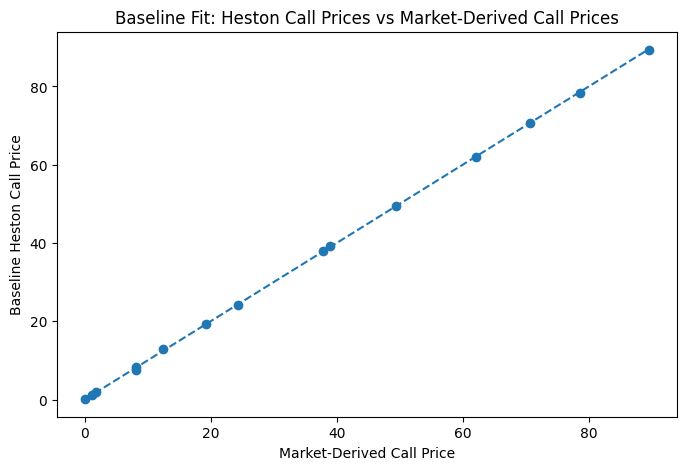

In [27]:
# Plotting market-derived call prices against baseline Heston call prices.

plt.figure(figsize=(8, 5))
plt.scatter(calibration_df["market_call"], calibration_df["baseline_heston_call"])

min_price = min(calibration_df["market_call"].min(), calibration_df["baseline_heston_call"].min())
max_price = max(calibration_df["market_call"].max(), calibration_df["baseline_heston_call"].max())

plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
plt.xlabel("Market-Derived Call Price")
plt.ylabel("Baseline Heston Call Price")
plt.title("Baseline Fit: Heston Call Prices vs Market-Derived Call Prices")
plt.show()

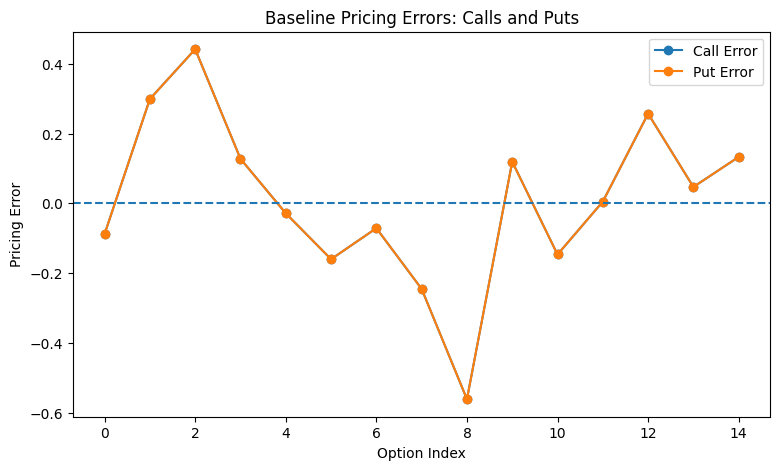

In [30]:
# Plot baseline pricing errors for calls and puts separately.

x = np.arange(len(calibration_df))

plt.figure(figsize=(9, 5))
plt.plot(x, calibration_df["call_error"].values, marker="o", label="Call Error")
plt.plot(x, calibration_df["put_error"].values, marker="o", label="Put Error")
plt.axhline(0, linestyle="--")

plt.xlabel("Option Index")
plt.ylabel("Pricing Error")
plt.title("Baseline Pricing Errors: Calls and Puts")
plt.legend()
plt.show()

### 4.3 Limitations of the Naive Baseline

Although the baseline method provides a useful benchmark, it has several important limitations.

First, L-BFGS-B is a local optimizer, so the final calibrated parameters can depend heavily on the initial guess. Since the Heston calibration objective is non-linear and may contain several local minima, a single-start approach can converge to a solution that is not globally reliable.

Second, the method may become unstable across different market conditions. Changing the valuation date, maturity set, or moneyness range can lead to different convergence behavior and different fitted parameters.

Third, the baseline method is computationally expensive. Each objective evaluation requires repeated Heston price calculations across calls and puts for multiple strikes and maturities. As the number of instruments increases, the runtime grows quickly.


In [31]:
# Testing sensitivity of the naive baseline to different starting values.

alternative_initial_guesses = [
    np.array([atm_vol**2, 1.0, atm_vol**2, 0.3, -0.3]),
    np.array([atm_vol**2, 3.0, atm_vol**2, 1.0, -0.7]),
    np.array([0.15, 5.0, 0.15, 2.0, -0.2]),
]

diagnostics = []

for guess in alternative_initial_guesses:
    objective_call_count["count"] = 0
    t0 = time.time()

    res = minimize(
        fun=calculate_mse_baseline,
        x0=guess,
        args=(calibration_df,),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 500,
            "ftol": 1e-10
        }
    )

    t1 = time.time()

    diagnostics.append({
        "initial_guess": guess,
        "final_mse": res.fun,
        "iterations": res.nit,
        "objective_evaluations": objective_call_count["count"],
        "runtime_sec": t1 - t0,
        "success": res.success
    })

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

,initial_guess,final_mse,iterations,objective_evaluations,runtime_sec,success
0,"[0.021898672324, 1.0, 0.021898672324, 0.3, -0.3]",0.111582,102,738,15.426872,True
1,"[0.021898672324, 3.0, 0.021898672324, 1.0, -0.7]",0.111582,88,666,12.330535,True
2,"[0.15, 5.0, 0.15, 2.0, -0.2]",0.111582,126,978,18.088018,True


The diagnostic results show that while the baseline method converges to the same final error of 0.111582 across different initial guesses, the computational effort varies significantly. Specifically, the number of iterations ranges from 88 to 126, the number of objective evaluations ranges from 666 to 978, and the runtime varies from approximately 12.33 seconds to 18.09 seconds. This indicates that although the optimizer reaches a similar solution, the convergence path is highly sensitive to initialization. Such variability highlights inefficiency and lack of robustness in the baseline method, particularly as the problem scales, thereby motivating the need for more stable and efficient calibration techniques.